# Walkthrough: one admixture graph, end to end

This notebook runs the benchmark pipeline on one known graph and checks every step.

1. Define a true admixture graph.
2. Build the msprime demography from it.
3. Simulate SNP genotypes.
4. Export them as EIGENSTRAT.
5. Compute f-statistics and check the admixture signal.
6. Fit the true topology with qpgraph. This is the sanity gate.
7. Search blind with find_graphs.
8. Compare the best inferred graph with the truth.

The graph has 5 ingroup populations (P1 to P5) and an outgroup (O). There is one admixture event: P3 is
founded from a P2-side lineage and a P5-side lineage. Every step calls the `admixbench` package, so this
is the same code the benchmark runs.

## Step 0: environment

Imports the package and checks that Rscript can load ADMIXTOOLS 2 and jsonlite. If R is missing, run
`./setup_r.sh` from the repo root.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import msprime
import numpy as np
import pandas as pd

from admixbench import admixtools, fstats, metrics
from admixbench.export import write_eigenstrat
from admixbench.graphspec import easy_graph
from admixbench.plotting import plot_comparison, plot_graph
from admixbench.simulate import build_demography, simulate

SEED = 1
SEQUENCE_LENGTH = 1e8     # about 600k SNPs, 50 jackknife blocks
NUMSTART = 50             # independent find_graphs runs
WORK = Path("../cache/walkthrough")
WORK.mkdir(parents=True, exist_ok=True)

print("msprime", msprime.__version__, "| Rscript", admixtools.RSCRIPT)
assert admixtools.r_available(), "Rscript cannot load admixtools and jsonlite: run ./setup_r.sh"
print("R with admixtools and jsonlite: OK")

msprime 1.3.4 | Rscript /opt/homebrew/bin/Rscript


R with admixtools and jsonlite: OK


## Step 1: the true graph

`GraphSpec` is the single source of truth. The msprime demography and the NetworkX graph are both
derived from it.

```
                 R
               /   \
              A     O
            /   \
         A_L     A_R
        /   \    /   \
      P1  A_L2  P4  A_R2
          /  \       /  \
        P2  srcA    P5  srcB
               \    /
                 P3 = 0.35 srcA + 0.65 srcB   (t = 100)
```

srcA and srcB are ghost lineages, sisters of P2 and P5. They sit on deeply diverged sides of the tree,
and the admixture is recent (100 generations), so P3 has drifted little since. That keeps
f3(P3; P2, P5) clearly negative. At t=400 it stayed positive.

**Expect:** 6 leaves, 1 admixture event, and a drawing with two red dashed edges into P3.

leaves: ('P1', 'P2', 'P3', 'P4', 'P5', 'O') | outgroup: O
  t=  100  Admixture Admixture(time=100, derived='P3', sources=('srcA', 'srcB'), proportions=(0.35, 0.65))
  t= 2000  Split     Split(time=2000, derived=('P2', 'srcA'), ancestral='A_L2')
  t= 2200  Split     Split(time=2200, derived=('P5', 'srcB'), ancestral='A_R2')
  t= 4000  Split     Split(time=4000, derived=('P1', 'A_L2'), ancestral='A_L')
  t= 4200  Split     Split(time=4200, derived=('P4', 'A_R2'), ancestral='A_R')
  t= 6000  Split     Split(time=6000, derived=('A_L', 'A_R'), ancestral='A')
  t= 8000  Split     Split(time=8000, derived=('A', 'O'), ancestral='R')


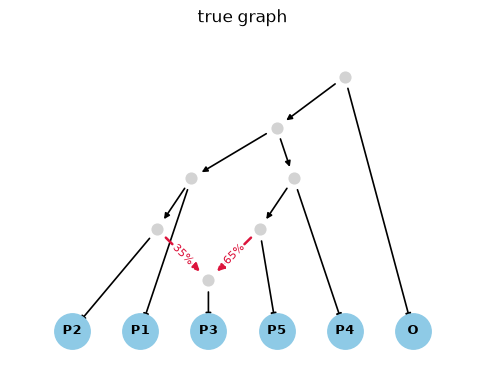

In [2]:
spec = easy_graph()
truth = spec.to_networkx()
print("leaves:", spec.leaves, "| outgroup:", spec.outgroup)
for e in spec.events():
    print(f"  t={e.time:>5}  {type(e).__name__:9s} {e}")
fig, ax = plt.subplots(figsize=(6, 4.5))
plot_graph(truth, ax, title="true graph");

## Step 2: msprime demography

Every population, leaf and ancestral, is declared first. Events are then added in increasing time
order. msprime runs backwards in time, so adding an earlier event after a later one fails with
"derived population must be active".

**Expect:** the admixture at t=100 first, then the splits in time order.

In [3]:
demo = build_demography(spec)
print("populations:", [p.name for p in demo.populations])
for e in demo.events:
    print(f"  t={e.time:>6}  {type(e).__name__}")

populations: ['P1', 'P2', 'P3', 'P4', 'P5', 'O', 'srcA', 'srcB', 'A_L2', 'A_R2', 'A_L', 'A_R', 'A', 'R']
  t=   100  Admixture
  t=  2000  PopulationSplit
  t=  2200  PopulationSplit
  t=  4000  PopulationSplit
  t=  4200  PopulationSplit
  t=  6000  PopulationSplit
  t=  8000  PopulationSplit


## Step 3: simulate genotypes

`sim_ancestry` with recombination, then binary mutations. Ne is 10,000 everywhere, and the
recombination and mutation rates are the measured human values (1e-8 and 1.25e-8 per bp per
generation). Ten diploids per leaf.

**Expect:** about 600k SNPs at 1e8 bp. This step takes a couple of minutes.

In [4]:
t0 = time.time()
ts = simulate(spec, sequence_length=SEQUENCE_LENGTH, seed=SEED)
print(f"{ts.num_samples} haplotypes, {ts.num_individuals} individuals, {ts.num_sites} SNPs ({time.time() - t0:.0f}s)")
pi = float(ts.diversity(sample_sets=[ts.samples(population=0)], mode="site")[0])
print(f"diversity in P1: {pi:.2e} per bp (4 Ne mu = {4 * 10_000 * 1.25e-8:.2e})")

120 haplotypes, 60 individuals, 624692 SNPs (123s)
diversity in P1: 4.98e-04 per bp (4 Ne mu = 5.00e-04)


## Step 4: export to EIGENSTRAT

ADMIXTOOLS 2 reads EIGENSTRAT or binary PLINK, not text PLINK. The `.snp` file uses the real site
positions. ADMIXTOOLS 2 cuts the genome into 2 Mb jackknife blocks by position. Positions squeezed into a
short range would give a single block and a covariance matrix that cannot be inverted.

**Expect:** one `.geno` row per SNP with one character per individual, positions spanning the whole
sequence, and `.ind` labels in msprime's sample order.

In [5]:
prefix = WORK / "sim"
info = write_eigenstrat(ts, prefix)
pos = np.loadtxt(f"{prefix}.snp", usecols=3, dtype=np.int64)
print(f"SNP count: {info['n_snps']}, individuals: {info['n_ind']}")
print(f"positions {pos.min()} .. {pos.max()}, about {pos.max() // 2_000_000 + 1} blocks of 2 Mb")
print("first .geno row:", open(f"{prefix}.geno").readline().strip())
print("first .ind rows:", [l.split() for l in open(f"{prefix}.ind").readlines()[:2]])

SNP count: 624641, individuals: 60
positions 247 .. 99999527, about 50 blocks of 2 Mb
first .geno row: 222212222222111202121221211221222222222212111000212222222222
first .ind rows: [['P1_1', 'U', 'P1'], ['P1_2', 'U', 'P1']]


## Step 5: f-statistics and the admixture signal

ADMIXTOOLS 2 `extract_f2` computes the f2 blocks that inference uses. `adjust_pseudohaploid=FALSE` is
required. Otherwise ADMIXTOOLS 2 may decide simulated diploids are pseudohaploid, and silently halve their
information.

In Python we compute the same statistics as a cross-check. f2 from the data should be a constant
multiple of the f2 the graph predicts, because Ne is constant. f3(P3; P2, P5) should be clearly negative
(Z below -3). That is the signature of P3 being a mix of the P2 side and the P5 side.

**Expect:** more than 1 jackknife block, a near-constant ratio column, and f3 with Z below -3.

In [6]:
n_blocks = admixtools.extract_f2(prefix, WORK / "f2")
print(f"ADMIXTOOLS 2 jackknife blocks: {n_blocks}")

data = fstats.read_eigenstrat(prefix)
expected = fstats.expected_f2(truth)
rows = []
for i, a in enumerate(data.pops):
    for b in data.pops[i + 1:]:
        s = fstats.f2(data, a, b)
        rows.append(dict(pair=f"{a}-{b}", f2=s.est, se=s.se, expected_drift=expected.loc[a, b],
                         ratio=s.est / expected.loc[a, b]))
f2_table = pd.DataFrame(rows)
print(f2_table.round(5).to_string(index=False))
print(f"ratio spread (max/min): {f2_table.ratio.max() / f2_table.ratio.min():.3f}")

f3 = fstats.f3(data, "P3", "P2", "P5")
print(f"\nf3(P3; P2, P5) = {f3.est:.5f}  SE {f3.se:.5f}  Z {f3.z:.2f}")
assert f3.z < -3, "admixture signal too weak to search for"
print("admixture signal: clearly negative")

ADMIXTOOLS 2 jackknife blocks: 50


 pair      f2      se  expected_drift   ratio
P1-P2 0.01672 0.00033         0.40000 0.04179
P1-P3 0.01617 0.00033         0.39578 0.04084
P1-P4 0.02413 0.00032         0.60000 0.04022
P1-P5 0.02450 0.00037         0.60000 0.04083
 P1-O 0.03262 0.00035         0.80000 0.04077
P2-P3 0.01327 0.00036         0.32578 0.04075
P2-P4 0.02429 0.00033         0.60000 0.04048
P2-P5 0.02441 0.00038         0.60000 0.04069
 P2-O 0.03217 0.00031         0.80000 0.04021
P3-P4 0.01360 0.00017         0.34878 0.03900
P3-P5 0.00882 0.00022         0.21878 0.04031
 P3-O 0.02671 0.00033         0.66578 0.04011
P4-P5 0.01670 0.00026         0.42000 0.03976
 P4-O 0.03216 0.00039         0.80000 0.04020
 P5-O 0.03230 0.00039         0.80000 0.04038
ratio spread (max/min): 1.071

f3(P3; P2, P5) = -0.00116  SE 0.00014  Z -8.43
admixture signal: clearly negative


## Step 6: qpgraph on the true topology

Fit the known topology to the data. The data were simulated under this graph, so it should fit. The bar
is a worst f4 residual under 3 standard errors. If the true graph does not fit its own data, the problem
is upstream, and no search result should be trusted.

**Expect:** worst residual well under 3, and PASS.

In [7]:
gate = admixtools.qpgraph_true(WORK / "f2", spec, WORK)
print(f"true topology: score {gate['score']:.3f}, worst residual |Z| {gate['worst_residual']:.2f}")
print("fitted admixture proportions:",
      [round(e['weight'], 3) for e in gate['edges'] if e['type'] == 'admix'])
assert gate["passed"], "the true graph does not fit its own data"
print("PASS")

true topology: score 4.468, worst residual |Z| 1.89
fitted admixture proportions: [0.344, 0.656]
PASS


## Step 7: blind search with find_graphs

find_graphs gets only the f2 blocks, the outgroup and the number of admixture events. One call is one
hill-climb from a random start, so we run it `NUMSTART` times in parallel and pool every graph it scored.
Lower score is better.

**Expect:** many distinct topologies, and a best score close to the true-topology score from Step 6.
This step takes several minutes. The result is cached.

In [8]:
t0 = time.time()
fg = admixtools.find_graphs(WORK / "f2", numadmix=1, outpop=spec.outgroup, numstart=NUMSTART, seed=SEED, workdir=WORK)
rows = fg["rows"]
print(f"{NUMSTART} runs, {len(rows)} distinct topologies ({time.time() - t0:.0f}s)")
print(f"best score {rows[0]['score']:.3f} (true topology {gate['score']:.3f})")
print("top 5 scores:", [round(r["score"], 3) for r in rows[:5]])

50 runs, 1211 distinct topologies (351s)
best score 4.468 (true topology 4.468)
top 5 scores: [4.468, 262.058, 262.058, 335.426, 379.096]


## Step 8: compare with the truth

The metrics from `admixbench.metrics`, applied to the best graph:

- **topology equal**: exact match. It is strict, so it is reported but not relied on.
- **set distance**: the primary structural metric. 0 means the same branching structure.
- **covariance distance**: how far apart the f2 predicted by the two fitted graphs are.
- **admixed check**: which leaves are admixed, and which leaves sit under each source.
- **rank of truth**: where the true topology appears in the ranked list.

**Expect:** P3 admixed, with one source above P2 and one above P5, set distance 0, and rank of truth 1.

In [9]:
best = admixtools.edges_to_networkx(rows[0]["edges"])
ranked = [admixtools.edges_to_networkx(r["edges"]) for r in rows]
acc = metrics.admixed_accuracy(truth, best)
H = metrics.canonicalize_admixture(best)
for x in sorted(acc["inferred_admixed"]):
    for u in H.predecessors(x):
        print(f"inferred: {x} gets {100 * H.edges[u, x]['proportion']:.0f}% from a source above "
              f"{sorted(metrics._desc_leaves(H, u) - {x})}")
print(f"true admixed {sorted(acc['true_admixed'])}, inferred {sorted(acc['inferred_admixed'])}, "
      f"sources correct {acc['sources_correct']}")
print(f"topology equal:      {metrics.topology_equality(truth, best)}")
print(f"set distance:        {metrics.set_distance(truth, best)}")
print(f"covariance distance: {metrics.covariance_distance(gate['fitted'], best):.2e}")
print(f"rank of truth:       {metrics.rank_of_truth(truth, ranked)}")

inferred: P3 gets 66% from a source above ['P5']
inferred: P3 gets 34% from a source above ['P2']
true admixed ['P3'], inferred ['P3'], sources correct {'P3': True}
topology equal:      True
set distance:        0
covariance distance: 1.08e-10
rank of truth:       1


## Truth and inferred, side by side

Both panels use the same function and conventions: blue leaves, grey internal nodes, black drift
edges, red dashed admixture edges with percentages. Both are canonicalized, so equivalent graphs look
alike. Internal node names differ because the search invents its own.

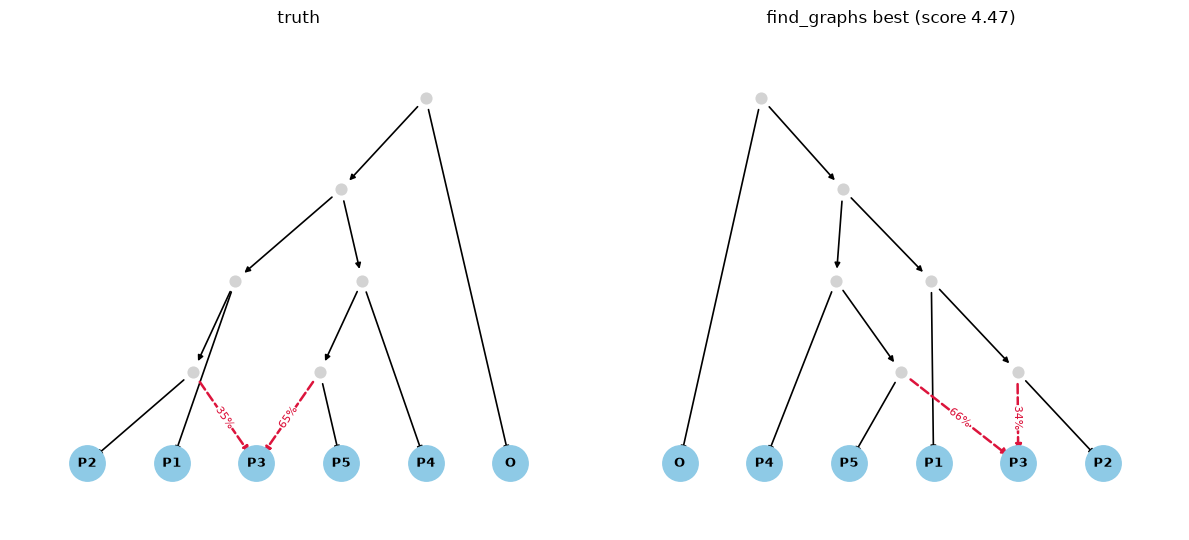

In [10]:
plot_comparison(truth, best, ("truth", f"find_graphs best (score {rows[0]['score']:.2f})"));

## Summary

If the f3 signal was clearly negative, the true topology passed the qpgraph gate, and the best graph
matched the truth, then the whole chain works on this graph: GraphSpec to msprime, to EIGENSTRAT, to
ADMIXTOOLS 2 f2, to find_graphs, and back to a scored comparison. The benchmark (`scripts/run_benchmark.py`)
runs this same chain over many graphs and seeds.